In [1]:
import sys
import os
import warnings
import logging
import json
from datetime import datetime
import pickle
import joblib

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# XGBoost, LightGBM, CatBoost
try:
    import xgboost as xgb
except ImportError:
    print("❌ XGBoost not installed. Run: pip install xgboost")
    
try:
    import lightgbm as lgb
except ImportError:
    print("❌ LightGBM not installed. Run: pip install lightgbm")
    
try:
    from catboost import CatBoostRegressor
except ImportError:
    print("❌ CatBoost not installed. Run: pip install catboost")

# MLflow for tracking
try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    print("❌ MLflow not installed. Run: pip install mlflow")

# Suppress warnings
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

c:\Users\touhi\Desktop\ML Projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration & Path Setup

In [4]:
# Configuration dictionary
CONFIG = {
    'data': {
        'train_path': '../data/splits/splits/X_train.csv',
        'val_path': '../data/splits/splits/X_val.csv',
        'test_path': '../data/splits/splits/X_test.csv',
        'y_train_low': '../data/splits/splits/y_train_low.csv',
        'y_train_mid': '../data/splits/splits/y_train_mid.csv',
        'y_val_low': '../data/splits/splits/y_val_low.csv',
        'y_val_mid': '../data/splits/splits/y_val_mid.csv',
        'y_test_low': '../data/splits/splits/y_test_low.csv',
        'y_test_mid': '../data/splits/splits/y_test_mid.csv'
    },
    'models': {
        'checkpoint_dir': '../models/checkpoints/',
        'final_dir': '../models/final/',
        'mlflow_dir': '../models/mlflow/'
    },
    'training': {
        'random_state': 42,
        'test_size': 0.2,
        'cv_folds': 5
    },
    'targets': {
        'low': 'Spending_Lowest_20',
        'mid': 'Spending_Middle_20'
    }
}

# Create directories if they don't exist
os.makedirs(CONFIG['models']['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['models']['final_dir'], exist_ok=True)
os.makedirs(CONFIG['models']['mlflow_dir'], exist_ok=True)

print("✅ Configuration loaded successfully!")
print(f"📁 Checkpoint directory: {CONFIG['models']['checkpoint_dir']}")
print(f"📁 Final models directory: {CONFIG['models']['final_dir']}")
print(f"📁 MLflow directory: {CONFIG['models']['mlflow_dir']}")

✅ Configuration loaded successfully!
📁 Checkpoint directory: ../models/checkpoints/
📁 Final models directory: ../models/final/
📁 MLflow directory: ../models/mlflow/


# Load Data

In [5]:
def load_data_with_check(filepath, description=""):
    try:
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        
        data = pd.read_csv(filepath)
        print(f"✅ Loaded {description}: {data.shape} - {filepath}")
        return data
    except Exception as e:
        print(f"❌ Error loading {description}: {str(e)}")
        return None

def load_all_data(config):
    print("\n" + "="*60)
    print("📊 LOADING DATA SPLITS")
    print("="*60)
    
    data = {}
    
    # Load feature data
    data['X_train'] = load_data_with_check(config['data']['train_path'], "X_train")
    data['X_val'] = load_data_with_check(config['data']['val_path'], "X_val")
    data['X_test'] = load_data_with_check(config['data']['test_path'], "X_test")
    
    # Load target data
    data['y_train_low'] = load_data_with_check(config['data']['y_train_low'], "y_train_low")
    data['y_train_mid'] = load_data_with_check(config['data']['y_train_mid'], "y_train_mid")
    data['y_val_low'] = load_data_with_check(config['data']['y_val_low'], "y_val_low")
    data['y_val_mid'] = load_data_with_check(config['data']['y_val_mid'], "y_val_mid")
    data['y_test_low'] = load_data_with_check(config['data']['y_test_low'], "y_test_low")
    data['y_test_mid'] = load_data_with_check(config['data']['y_test_mid'], "y_test_mid")
    
    # Check if any data failed to load
    failed = [k for k, v in data.items() if v is None]
    if failed:
        print(f"\n❌ Failed to load: {', '.join(failed)}")
        return None
    
    print("\n" + "="*60)
    print("✅ ALL DATA LOADED SUCCESSFULLY!")
    print("="*60)
    
    return data

# Load the data
DATA = load_all_data(CONFIG)

# Verify data shapes
if DATA:
    print("\n📊 Data Shapes:")
    print(f"  X_train: {DATA['X_train'].shape}")
    print(f"  X_val:   {DATA['X_val'].shape}")
    print(f"  X_test:  {DATA['X_test'].shape}")
    print(f"  y_train_low: {DATA['y_train_low'].shape}")
    print(f"  y_train_mid: {DATA['y_train_mid'].shape}")


📊 LOADING DATA SPLITS
✅ Loaded X_train: (144, 39) - ../data/splits/splits/X_train.csv
✅ Loaded X_val: (48, 39) - ../data/splits/splits/X_val.csv
✅ Loaded X_test: (48, 39) - ../data/splits/splits/X_test.csv
✅ Loaded y_train_low: (144, 1) - ../data/splits/splits/y_train_low.csv
✅ Loaded y_train_mid: (144, 1) - ../data/splits/splits/y_train_mid.csv
✅ Loaded y_val_low: (48, 1) - ../data/splits/splits/y_val_low.csv
✅ Loaded y_val_mid: (48, 1) - ../data/splits/splits/y_val_mid.csv
✅ Loaded y_test_low: (48, 1) - ../data/splits/splits/y_test_low.csv
✅ Loaded y_test_mid: (48, 1) - ../data/splits/splits/y_test_mid.csv

✅ ALL DATA LOADED SUCCESSFULLY!

📊 Data Shapes:
  X_train: (144, 39)
  X_val:   (48, 39)
  X_test:  (48, 39)
  y_train_low: (144, 1)
  y_train_mid: (144, 1)


# Data Validation

In [6]:
def validate_data(data):
    print("\n" + "="*60)
    print("🔍 DATA VALIDATION")
    print("="*60)
    
    all_valid = True
    
    # Check for missing values
    for name, df in data.items():
        if df is not None:
            missing = df.isnull().sum().sum()
            if missing > 0:
                print(f"⚠️  {name} has {missing} missing values")
                all_valid = False
            else:
                print(f"✅ {name}: No missing values")
    
    # Check target values
    targets = ['y_train_low', 'y_train_mid', 'y_val_low', 'y_val_mid', 'y_test_low', 'y_test_mid']
    for target in targets:
        if target in data and data[target] is not None:
            df = data[target]
            print(f"\n📊 {target} statistics:")
            print(f"  Mean: {df.iloc[:,0].mean():.3f}")
            print(f"  Std:  {df.iloc[:,0].std():.3f}")
            print(f"  Min:  {df.iloc[:,0].min():.3f}")
            print(f"  Max:  {df.iloc[:,0].max():.3f}")
            
            # Check for negative values
            if (df.iloc[:,0] < 0).any():
                print(f"  ⚠️  Contains negative values!")
                all_valid = False
    
    # Check feature data types
    if 'X_train' in data and data['X_train'] is not None:
        print("\n📊 Feature Data Types:")
        print(data['X_train'].dtypes.value_counts())
    
    print("\n" + "="*60)
    if all_valid:
        print("✅ DATA VALIDATION PASSED!")
    else:
        print("⚠️  DATA VALIDATION COMPLETED WITH WARNINGS")
    print("="*60)
    
    return all_valid

validate_data(DATA)


🔍 DATA VALIDATION
✅ X_train: No missing values
✅ X_val: No missing values
✅ X_test: No missing values
✅ y_train_low: No missing values
✅ y_train_mid: No missing values
✅ y_val_low: No missing values
✅ y_val_mid: No missing values
✅ y_test_low: No missing values
✅ y_test_mid: No missing values

📊 y_train_low statistics:
  Mean: 4.525
  Std:  4.802
  Min:  0.290
  Max:  25.892

📊 y_train_mid statistics:
  Mean: 7.889
  Std:  6.807
  Min:  0.560
  Max:  25.892

📊 y_val_low statistics:
  Mean: 5.092
  Std:  5.253
  Min:  0.360
  Max:  25.892

📊 y_val_mid statistics:
  Mean: 8.760
  Std:  7.399
  Min:  0.680
  Max:  25.892

📊 y_test_low statistics:
  Mean: 5.201
  Std:  5.232
  Min:  0.370
  Max:  25.892

📊 y_test_mid statistics:
  Mean: 9.180
  Std:  7.644
  Min:  0.700
  Max:  25.892

📊 Feature Data Types:
float64    34
int64       5
Name: count, dtype: int64

✅ DATA VALIDATION PASSED!


True

# Feature Preparation

In [7]:
def prepare_features(data):
    print("\n" + "="*60)
    print("🔧 PREPARING FEATURES")
    print("="*60)
    
    X_train = data['X_train'].copy()
    X_val = data['X_val'].copy()
    X_test = data['X_test'].copy()
    
    feature_names = X_train.columns.tolist()
    
    print(f"✅ Features: {len(feature_names)} total")
    print(f"  Training: {X_train.shape}")
    print(f"  Validation: {X_val.shape}")
    print(f"  Test: {X_test.shape}")
    
    return X_train, X_val, X_test, feature_names

X_train, X_val, X_test, feature_names = prepare_features(DATA)

# Check feature consistency across splits
print("\n✅ Feature consistency check:")
print(f"  Train features: {len(X_train.columns)}")
print(f"  Val features:   {len(X_val.columns)}")
print(f"  Test features:  {len(X_test.columns)}")

if len(set(X_train.columns) - set(X_val.columns)) == 0:
    print("  ✅ All features match across splits!")
else:
    print("  ⚠️  Feature mismatch detected!")


🔧 PREPARING FEATURES
✅ Features: 39 total
  Training: (144, 39)
  Validation: (48, 39)
  Test: (48, 39)

✅ Feature consistency check:
  Train features: 39
  Val features:   39
  Test features:  39
  ✅ All features match across splits!


# Extract Target Variables

In [8]:
def prepare_targets(data):
    print("\n" + "="*60)
    print("🎯 PREPARING TARGET VARIABLES")
    print("="*60)
    
    targets = {}
    
    # Training targets
    targets['y_train_low'] = data['y_train_low'].iloc[:, 0].values
    targets['y_train_mid'] = data['y_train_mid'].iloc[:, 0].values
    
    # Validation targets
    targets['y_val_low'] = data['y_val_low'].iloc[:, 0].values
    targets['y_val_mid'] = data['y_val_mid'].iloc[:, 0].values
    
    # Test targets
    targets['y_test_low'] = data['y_test_low'].iloc[:, 0].values
    targets['y_test_mid'] = data['y_test_mid'].iloc[:, 0].values
    
    print(f"✅ Training set: {len(targets['y_train_low'])} samples")
    print(f"✅ Validation set: {len(targets['y_val_low'])} samples")
    print(f"✅ Test set: {len(targets['y_test_low'])} samples")
    
    print(f"\n📊 Low Income Target:")
    print(f"  Train mean: {targets['y_train_low'].mean():.3f}")
    print(f"  Val mean:   {targets['y_val_low'].mean():.3f}")
    print(f"  Test mean:  {targets['y_test_low'].mean():.3f}")
    
    print(f"\n📊 Middle Income Target:")
    print(f"  Train mean: {targets['y_train_mid'].mean():.3f}")
    print(f"  Val mean:   {targets['y_val_mid'].mean():.3f}")
    print(f"  Test mean:  {targets['y_test_mid'].mean():.3f}")
    
    return targets

TARGETS = prepare_targets(DATA)


🎯 PREPARING TARGET VARIABLES
✅ Training set: 144 samples
✅ Validation set: 48 samples
✅ Test set: 48 samples

📊 Low Income Target:
  Train mean: 4.525
  Val mean:   5.092
  Test mean:  5.201

📊 Middle Income Target:
  Train mean: 7.889
  Val mean:   8.760
  Test mean:  9.180


# Model Definition

In [ ]:
def get_baseline_models(random_state=42):
    
    models = {
        'Dummy_Mean': DummyRegressor(strategy='mean'),
        'Dummy_Median': DummyRegressor(strategy='median'),
        'Linear_Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0, random_state=random_state),
        'Lasso': Lasso(alpha=1.0, random_state=random_state),
        'Random_Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=-1
        ),
        'XGBoost': xgb.XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            n_jobs=-1
        ),
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state,
            n_jobs=-1,
            verbose=-1
        ),
        'CatBoost': CatBoostRegressor(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            random_seed=random_state,
            verbose=False,
            thread_count=-1
        )
    }
    
    print(f"✅ Defined {len(models)} baseline models")
    return models

MODELS = get_baseline_models(CONFIG['training']['random_state'])

# Display model list
print("\n📋 Model List:")
for name in MODELS.keys():
    print(f"  - {name}")

✅ Defined 9 baseline models

📋 Model List:
  - Dummy_Mean
  - Dummy_Median
  - Linear_Regression
  - Ridge
  - Lasso
  - Random_Forest
  - XGBoost
  - LightGBM
  - CatBoost


# Evaluation Metrics Function

In [12]:
def calculate_regression_metrics(y_true, y_pred):
    
    metrics = {}
    
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['RMSE'] = rmse
    
    # MAE
    mae = mean_absolute_error(y_true, y_pred)
    metrics['MAE'] = mae
    
    # R²
    r2 = r2_score(y_true, y_pred)
    metrics['R2'] = r2
    
    # MAPE (Mean Absolute Percentage Error)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        metrics['MAPE'] = mape if np.isfinite(mape) else np.inf
    
    # Adjusted R² (penalizes complexity)
    n = len(y_true)
    p = 1  # Simplified - would need number of features for proper calculation
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else r2
    metrics['Adj_R2'] = adj_r2
    
    return metrics

def print_metrics(metrics, model_name=""):
   
    print(f"\n📊 {model_name} Performance:")
    print("-" * 40)
    for metric, value in metrics.items():
        if metric == 'MAPE':
            print(f"  {metric}: {value:.2f}%")
        else:
            print(f"  {metric}: {value:.4f}")

In [13]:
# Model Training Function

def train_model(model, model_name, X_train, y_train, X_val, y_val, target_group):
    print(f"\n{'='*60}")
    print(f"🚀 Training {model_name} - {target_group.upper()} Income")
    print(f"{'='*60}")
    
    result = {
        'model_name': model_name,
        'target_group': target_group,
        'status': 'failed'
    }
    
    try:
        # Train the model
        model.fit(X_train, y_train)
        result['status'] = 'trained'
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # Calculate metrics
        train_metrics = calculate_regression_metrics(y_train, y_train_pred)
        val_metrics = calculate_regression_metrics(y_val, y_val_pred)
        
        result['y_train_pred'] = y_train_pred
        result['y_val_pred'] = y_val_pred
        result['train_metrics'] = train_metrics
        result['val_metrics'] = val_metrics
        result['model'] = model
        
        # Print results
        print(f"✅ Training complete!")
        print_metrics(train_metrics, f"{model_name} - Train")
        print_metrics(val_metrics, f"{model_name} - Validation")
        
        result['status'] = 'success'
        
    except Exception as e:
        print(f"❌ Error training {model_name}: {str(e)}")
        result['status'] = 'error'
        result['error_message'] = str(e)
    
    return result

In [15]:
# Train All Models
def train_all_models(models, X_train, X_val, targets, target_col):
    
    print(f"\n{'#'*60}")
    print(f"🏋️ TRAINING ALL MODELS - {target_col.upper()} INCOME")
    print(f"{'#'*60}")
    
    # Get targets
    if target_col == 'low':
        y_train = targets['y_train_low']
        y_val = targets['y_val_low']
    else:
        y_train = targets['y_train_mid']
        y_val = targets['y_val_mid']
    
    results = {}
    
    for model_name, model in models.items():
        result = train_model(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            target_group=target_col
        )
        
        results[model_name] = result
    
    return results

# Train for LOW income
results_low = train_all_models(
    MODELS, X_train, X_val, TARGETS, 'low'
)

# Train for MIDDLE income
results_mid = train_all_models(
    MODELS, X_train, X_val, TARGETS, 'mid'
)

print(f"\n{'='*60}")
print("✅ ALL MODELS TRAINED!")
print(f"  Low Income: {len([r for r in results_low.values() if r['status'] == 'success'])}/{len(results_low)} successful")
print(f"  Middle Income: {len([r for r in results_mid.values() if r['status'] == 'success'])}/{len(results_mid)} successful")
print(f"{'='*60}")


############################################################
🏋️ TRAINING ALL MODELS - LOW INCOME
############################################################

🚀 Training Dummy_Mean - LOW Income
✅ Training complete!

📊 Dummy_Mean - Train Performance:
----------------------------------------
  RMSE: 4.7850
  MAE: 3.3166
  R2: 0.0000
  MAPE: 147.87%
  Adj_R2: -0.0070

📊 Dummy_Mean - Validation Performance:
----------------------------------------
  RMSE: 5.2287
  MAE: 3.5724
  R2: -0.0119
  MAPE: 129.09%
  Adj_R2: -0.0339

🚀 Training Dummy_Median - LOW Income
✅ Training complete!

📊 Dummy_Median - Train Performance:
----------------------------------------
  RMSE: 5.1558
  MAE: 2.9100
  R2: -0.1610
  MAPE: 77.48%
  Adj_R2: -0.1692

📊 Dummy_Median - Validation Performance:
----------------------------------------
  RMSE: 5.7621
  MAE: 3.3109
  R2: -0.2289
  MAPE: 69.88%
  Adj_R2: -0.2556

🚀 Training Linear_Regression - LOW Income
✅ Training complete!

📊 Linear_Regression - Train Performan

# Results Compilation & Comparison

In [17]:
# Compile Results
def compile_results(results_low, results_mid):
    
    # Compile low income results
    low_data = []
    for model_name, result in results_low.items():
        if result['status'] == 'success':
            row = {
                'Model': model_name,
                'RMSE_Train': result['train_metrics']['RMSE'],
                'RMSE_Val': result['val_metrics']['RMSE'],
                'MAE_Train': result['train_metrics']['MAE'],
                'MAE_Val': result['val_metrics']['MAE'],
                'R2_Train': result['train_metrics']['R2'],
                'R2_Val': result['val_metrics']['R2'],
                'MAPE_Train': result['train_metrics']['MAPE'],
                'MAPE_Val': result['val_metrics']['MAPE']
            }
            low_data.append(row)
    
    df_low = pd.DataFrame(low_data)
    
    # Compile middle income results
    mid_data = []
    for model_name, result in results_mid.items():
        if result['status'] == 'success':
            row = {
                'Model': model_name,
                'RMSE_Train': result['train_metrics']['RMSE'],
                'RMSE_Val': result['val_metrics']['RMSE'],
                'MAE_Train': result['train_metrics']['MAE'],
                'MAE_Val': result['val_metrics']['MAE'],
                'R2_Train': result['train_metrics']['R2'],
                'R2_Val': result['val_metrics']['R2'],
                'MAPE_Train': result['train_metrics']['MAPE'],
                'MAPE_Val': result['val_metrics']['MAPE']
            }
            mid_data.append(row)
    
    df_mid = pd.DataFrame(mid_data)
    
    # Create comparison DataFrame
    comparison_data = []
    for model_name, result_low in results_low.items():
        result_mid = results_mid.get(model_name)
        if result_low['status'] == 'success' and result_mid and result_mid['status'] == 'success':
            row = {
                'Model': model_name,
                'Low_RMSE_Val': result_low['val_metrics']['RMSE'],
                'Mid_RMSE_Val': result_mid['val_metrics']['RMSE'],
                'RMSE_Diff': result_low['val_metrics']['RMSE'] - result_mid['val_metrics']['RMSE'],
                'Low_R2_Val': result_low['val_metrics']['R2'],
                'Mid_R2_Val': result_mid['val_metrics']['R2'],
                'R2_Diff': result_low['val_metrics']['R2'] - result_mid['val_metrics']['R2']
            }
            comparison_data.append(row)
    
    df_comparison = pd.DataFrame(comparison_data)
    
    return df_low, df_mid, df_comparison

# Compile results
df_low, df_mid, df_comparison = compile_results(results_low, results_mid)

print("\n" + "="*60)
print("📊 LOW INCOME RESULTS")
print("="*60)
print(df_low.to_string(index=False))

print("\n" + "="*60)
print("📊 MIDDLE INCOME RESULTS")
print("="*60)
print(df_mid.to_string(index=False))

print("\n" + "="*60)
print("📊 COMPARISON: LOW vs MIDDLE")
print("="*60)
print(df_comparison.to_string(index=False))


📊 LOW INCOME RESULTS
            Model   RMSE_Train     RMSE_Val    MAE_Train      MAE_Val  R2_Train    R2_Val   MAPE_Train     MAPE_Val
       Dummy_Mean 4.784982e+00 5.228676e+00 3.316645e+00 3.572354e+00  0.000000 -0.011886 1.478696e+02 1.290937e+02
     Dummy_Median 5.155830e+00 5.762091e+00 2.910035e+00 3.310885e+00 -0.161012 -0.228877 7.747727e+01 6.987860e+01
Linear_Regression 3.427626e-14 1.592591e-11 2.290028e-14 1.592586e-11  1.000000  1.000000 1.136686e-12 6.938344e-10
            Ridge 3.297856e-02 3.136016e-02 2.125179e-02 2.048929e-02  0.999952  0.999964 6.326657e-01 6.938425e-01
            Lasso 7.294768e-01 7.729697e-01 3.071465e-01 3.527304e-01  0.976759  0.977886 7.718184e+00 7.528925e+00
    Random_Forest 5.754831e-01 5.306341e-01 1.596373e-01 1.859507e-01  0.985535  0.989578 2.371419e+00 2.960979e+00
          XGBoost 1.400470e-02 3.857273e-01 9.807755e-03 1.760734e-01  0.999991  0.994493 4.186081e-01 4.462943e+00
         LightGBM 1.100240e+00 1.238472e+00 5.0510

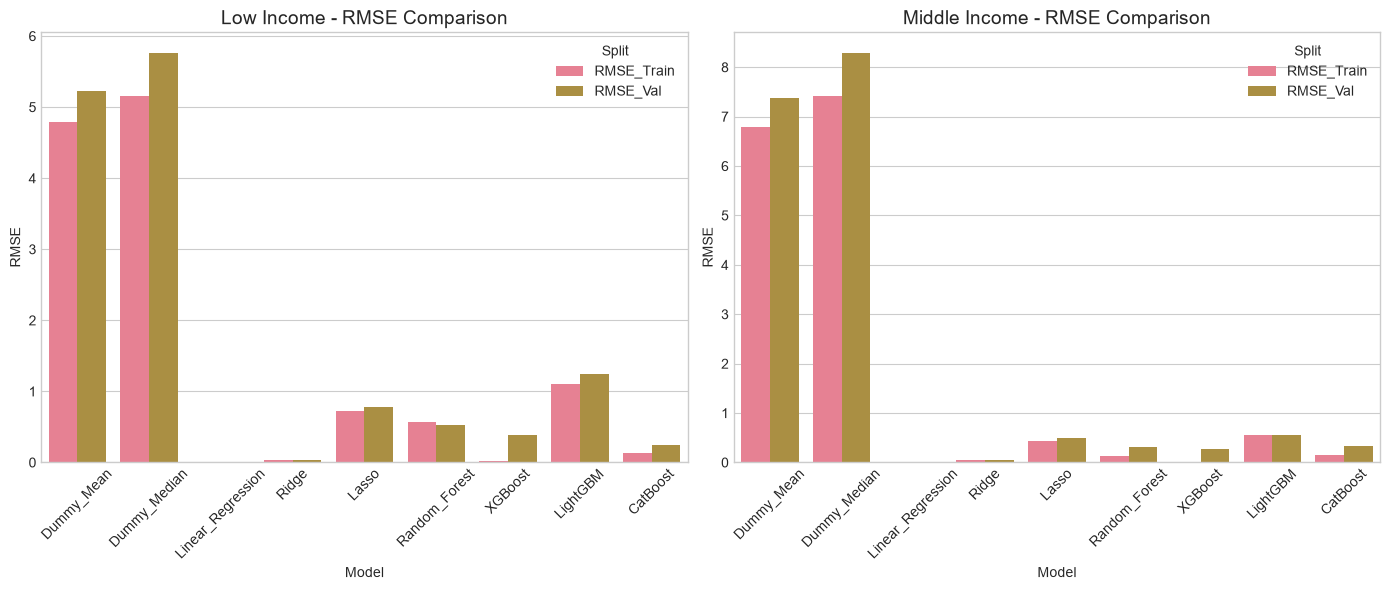

✅ RMSE comparison plot saved!


In [19]:
# Visualization
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Figure: RMSE Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Low income RMSE
df_low_melted = df_low[['Model', 'RMSE_Train', 'RMSE_Val']].melt(
    id_vars=['Model'], var_name='Split', value_name='RMSE'
)
sns.barplot(data=df_low_melted, x='Model', y='RMSE', hue='Split', ax=axes[0])
axes[0].set_title('Low Income - RMSE Comparison', fontsize=14)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# Middle income RMSE
df_mid_melted = df_mid[['Model', 'RMSE_Train', 'RMSE_Val']].melt(
    id_vars=['Model'], var_name='Split', value_name='RMSE'
)
sns.barplot(data=df_mid_melted, x='Model', y='RMSE', hue='Split', ax=axes[1])
axes[1].set_title('Middle Income - RMSE Comparison', fontsize=14)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ RMSE comparison plot saved!")

In [20]:
# Save Checkpoints
def save_checkpoints(results, target_group, config):
    print(f"\n💾 Saving checkpoints for {target_group.upper()} income...")
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    checkpoint_dir = config['models']['checkpoint_dir']
    
    # Save results as CSV
    if target_group == 'low':
        results_df = df_low
    else:
        results_df = df_mid
    
    csv_path = f"{checkpoint_dir}/results_{target_group}_{timestamp}.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"  ✅ Saved results: {csv_path}")
    
    # Save models
    saved_models = []
    for model_name, result in results.items():
        if result['status'] == 'success' and 'model' in result:
            model_path = f"{checkpoint_dir}/model_{target_group}_{model_name}_{timestamp}.pkl"
            joblib.dump(result['model'], model_path)
            saved_models.append(model_path)
            print(f"  ✅ Saved model: {model_path}")
    
    # Save summary metadata
    summary = {
        'timestamp': timestamp,
        'target_group': target_group,
        'n_models': len(results),
        'successful_models': len(saved_models),
        'best_model': results_df.iloc[0]['Model'] if not results_df.empty else None,
        'best_rmse_val': results_df.iloc[0]['RMSE_Val'] if not results_df.empty else None
    }
    
    summary_path = f"{checkpoint_dir}/summary_{target_group}_{timestamp}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"  ✅ Saved summary: {summary_path}")

# Save checkpoints
save_checkpoints(results_low, 'low', CONFIG)
save_checkpoints(results_mid, 'mid', CONFIG)

print("\n✅ All checkpoints saved successfully!")
print(f"📁 Location: {CONFIG['models']['checkpoint_dir']}")


💾 Saving checkpoints for LOW income...
  ✅ Saved results: ../models/checkpoints//results_low_20260812_034843.csv
  ✅ Saved model: ../models/checkpoints//model_low_Dummy_Mean_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_Dummy_Median_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_Linear_Regression_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_Ridge_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_Lasso_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_Random_Forest_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_XGBoost_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_LightGBM_20260812_034843.pkl
  ✅ Saved model: ../models/checkpoints//model_low_CatBoost_20260812_034843.pkl
  ✅ Saved summary: ../models/checkpoints//summary_low_20260812_034843.json

💾 Saving checkpoints for MID income...
  ✅ Saved results: ../models/checkpoints//resul

In [22]:
# Summary
print("\n" + "="*60)
print("📋 PHASE 1 COMPLETE: BASELINE MODEL TRAINING")
print("="*60)

# Best models
best_low = df_low.iloc[0] if not df_low.empty else None
best_mid = df_mid.iloc[0] if not df_mid.empty else None

print("\n🏆 BEST PERFORMING MODELS:")

if best_low is not None:
    print(f"\n  LOW INCOME:")
    print(f"    Model: {best_low['Model']}")
    print(f"    Validation RMSE: {best_low['RMSE_Val']:.4f}")
    print(f"    Validation R²: {best_low['R2_Val']:.4f}")

if best_mid is not None:
    print(f"\n  MIDDLE INCOME:")
    print(f"    Model: {best_mid['Model']}")
    print(f"    Validation RMSE: {best_mid['RMSE_Val']:.4f}")
    print(f"    Validation R²: {best_mid['R2_Val']:.4f}")

print("\n📂 OUTPUTS GENERATED:")
print(f"  ✅ Checkpoints saved in: {CONFIG['models']['checkpoint_dir']}")
print(f"  ✅ Results saved as CSV files")
print(f"  ✅ Model serialized as .pkl files")



📋 PHASE 1 COMPLETE: BASELINE MODEL TRAINING

🏆 BEST PERFORMING MODELS:

  LOW INCOME:
    Model: Dummy_Mean
    Validation RMSE: 5.2287
    Validation R²: -0.0119

  MIDDLE INCOME:
    Model: Dummy_Mean
    Validation RMSE: 7.3731
    Validation R²: -0.0141

📂 OUTPUTS GENERATED:
  ✅ Checkpoints saved in: ../models/checkpoints/
  ✅ Results saved as CSV files
  ✅ Model serialized as .pkl files
